# Evaluating k-means clustering

## Imported required libraries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from numpy.typing import ArrayLike, NDArray
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_classification
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

%matplotlib inline

## Clustering evaluation function

<p>We'll define a function for evaluating the clustering models we'll be building. We'll include silhouette scores and the Davies-Bouldin index, plus generate a plot displaying the silhouette scores.</p>

In [2]:
def evaluate_clustering(x: NDArray, labels: ArrayLike, n_clusters: int, ax: Axes | None = None, title_suffix: str = ""):
    ax = plt.gca() if ax is None else ax

    silhouette_avg = silhouette_score(x, labels)
    sample_silhouette_values = silhouette_samples(x, labels)

    unique_labels = np.unique(labels)
    cm_tab10 = mpl.colormaps["tab10"]
    color_dict = {label: cm_tab10(float(label) / n_clusters) for label in unique_labels}
    y_lower = 10

    for _i in unique_labels:
        ith_cluster_silhouette_values = sample_silhouette_values[labels == _i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = color_dict[_i]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(_i))
        y_lower = y_upper + 10

    ax.set_title(f"Silhouette Score for {title_suffix}\nAverage Silhouette: {silhouette_avg:.2f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_xlim((-0.25, 1.0))
    ax.set_yticks([])

## Create synthetic data with four blobs to experiment with k-means clustering

<p>Here we'll make some synthetic data consisting of slightly overlapping blobs, then run and evaluate k-means with <code>k = 4</code> clusters.</p>

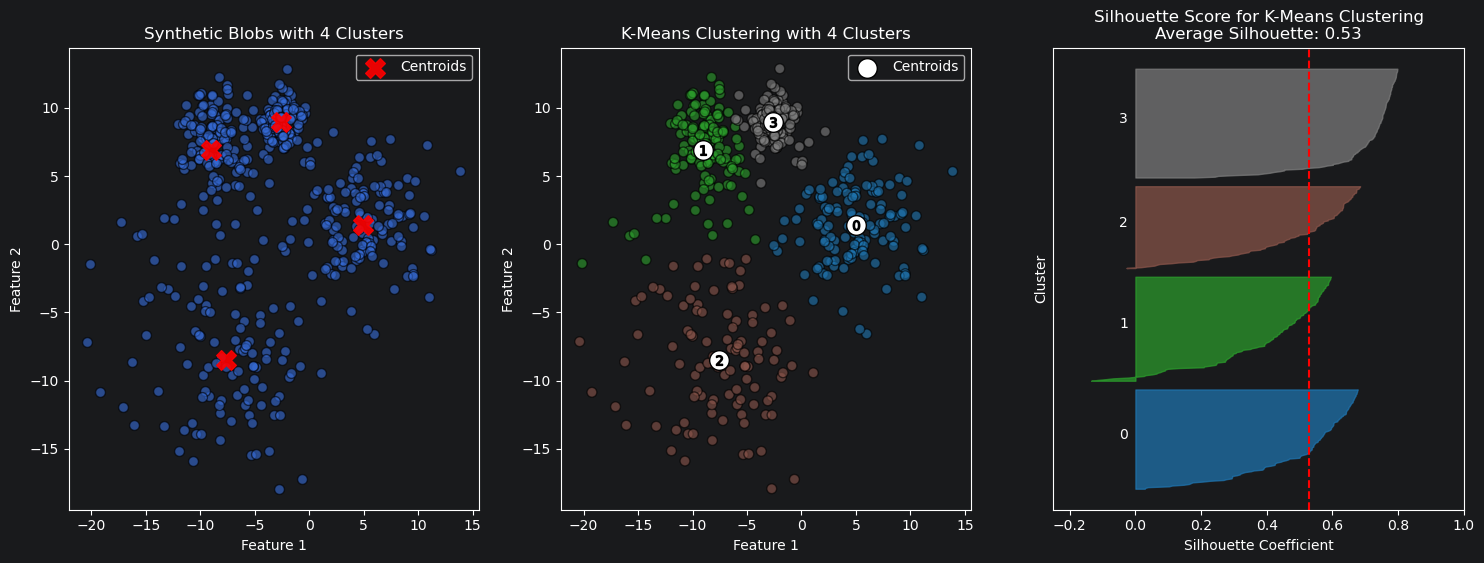

In [3]:
blobs: tuple[NDArray[np.float64], NDArray[np.int64]] = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=[1.0, 3, 5, 2], random_state=42)
X, y = blobs

nc = 4
kmeans = KMeans(n_clusters=nc, random_state=42)
y_kmeans: NDArray[np.int32] = kmeans.fit_predict(X)

colormap = mpl.colormaps["tab10"]

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6, edgecolor="k")

centers: NDArray[np.float64] = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="X", alpha=0.9, label="Centroids")
plt.title(f"Synthetic Blobs with {nc} Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

colors = colormap(y_kmeans.astype(float) / nc)
plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=colors, s=50, alpha=0.6, edgecolor="k")
plt.scatter(centers[:, 0], centers[:, 1], marker="o", c="white", alpha=1, s=200, edgecolor="k", label="Centroids")

for i, c in enumerate(centers):
    plt.scatter(c[0], c[1], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

plt.title(f"K-Means Clustering with {nc} Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.subplot(1, 3, 3)
evaluate_clustering(X, y_kmeans, nc, title_suffix="K-Means Clustering")

<p>Each point in a silhouette plot has a silhouette score ranging from <code>-1</code> to <code>1</code>. A high silhouette score indicates the data point is much more similar to its own cluster that its neighboring clusters. A score near 0 implies the point is at or near the decision boundary between two clusters. A negative score means the point might have been assigned to the wrong cluster. We'll take a closer look at the silhouette plot later.</p>
<p>The clustering result is quite plausible, particularly because we already know that there are four blobs in the synthetic data. Practically however, we would not have such information.</p>

## Cluster Stability

<p>How do the results change when K-means is run using different initial centroid seeds?</p>
<p>To assess stability, we can measure <code>inertia</code> and repeatedly vary the random initialization of cluster centers to observe the impact of having different initial centroid locations.</p>
<p>Inertia measures the compactness of clusters in K-means. It is defined as the sum of squared distances between each data point and its cluster centroid. Lower inertia values indicate more compact clusters and a potentially better clustering outcome. However, inertia tends to decrease as the number of clusters increases, so it's important to interpret it alongside other metrics.</p>
<p>To evaluate the stability of clustering, running k-means multiple times with different initial centroids by not fixing the random state helps determine if the algorithm consistently produces similar cluster assignments and inertia scores. Consistent inertia across runs suggests a stable solution that is less dependent on initial centroid positions.</p>

Run 1: Inertia = 7633.68
Run 2: Inertia = 8575.44
Run 3: Inertia = 7633.51
Run 4: Inertia = 8632.10
Run 5: Inertia = 7633.51
Run 6: Inertia = 8556.67
Run 7: Inertia = 7633.51
Run 8: Inertia = 8556.67


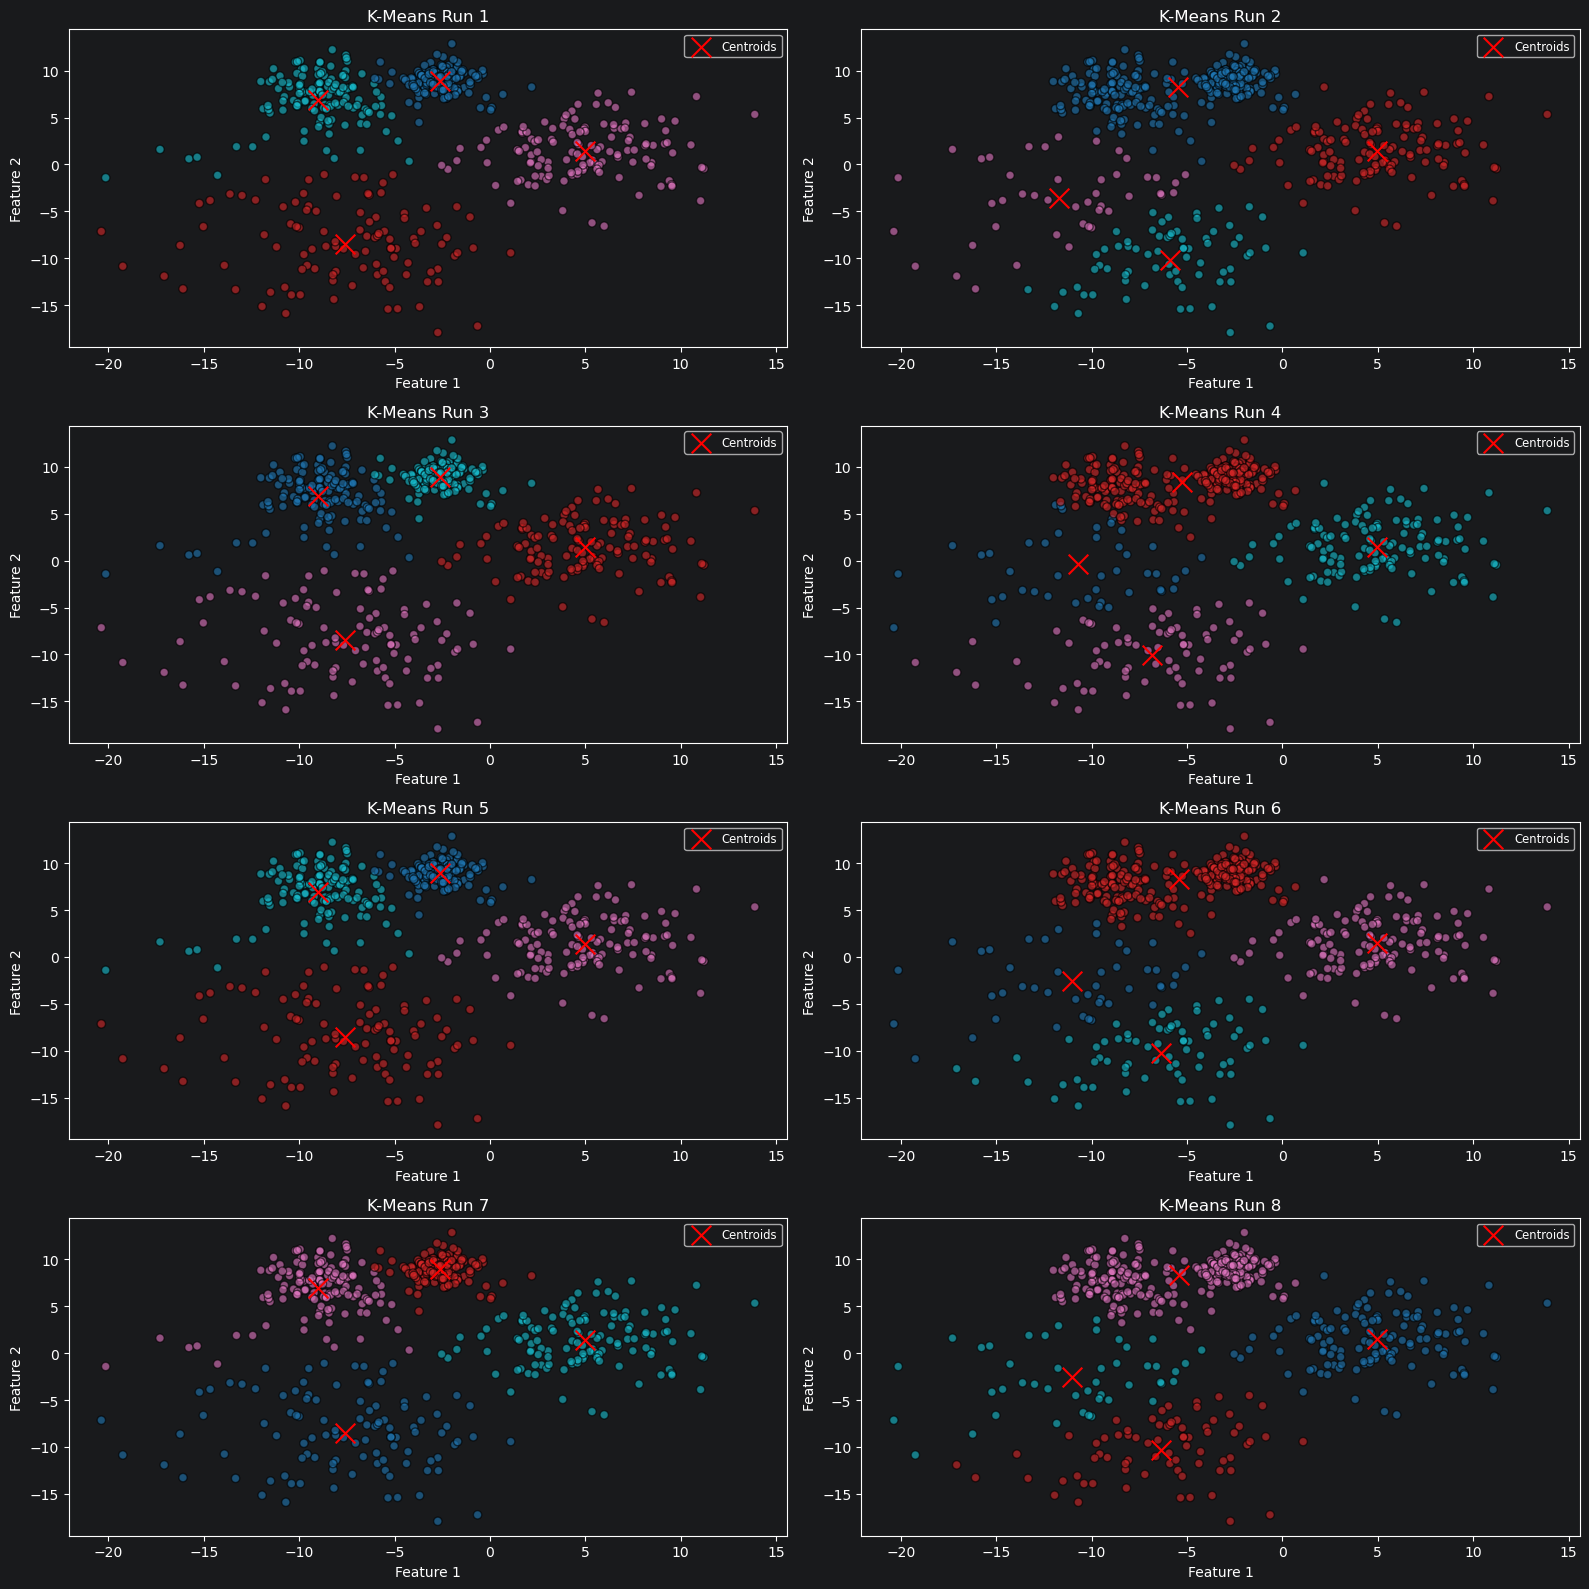

In [4]:
n_runs = 8
inertia_values = []

n_cols = 2
n_rows = -(-n_runs // n_cols)

plt.figure(figsize=(16, 16))
for i in range(n_runs):
    kmeans = KMeans(n_clusters=4, random_state=None)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="tab10", alpha=0.6, edgecolor="k")
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="red", s=200, marker="x", label="Centroids")
    plt.title(f"K-Means Run {i + 1}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(loc="upper right", fontsize="small")

plt.tight_layout()

for i, inertia in enumerate(inertia_values, start=1):
    print(f"Run {i}: Inertia = {inertia:.2f}")

<p>As demonstrated by the clustering results, the cluster assignments vary between runs when using different initial centroid seeds. Additionally, the inertia values show inconsistency, indicating that the clustering process is sensitive to the initial placement of centroids. This inertial inconsistency implies an less reliable result.</p>

## Number of clusters

<p>How do performance metrics change as the number of clusters increases? Can this analysis guide you in determining the optimal number of clusters ?</p>
<p>To explore this, we can examine how varying the value of K affects key metrics such as inertia, the Davies-Bouldin index, and silhouette scores. By plotting these score as a function of K, we can analyze the results and potentially gain insights into the optimal number of clusters for our data.</p>

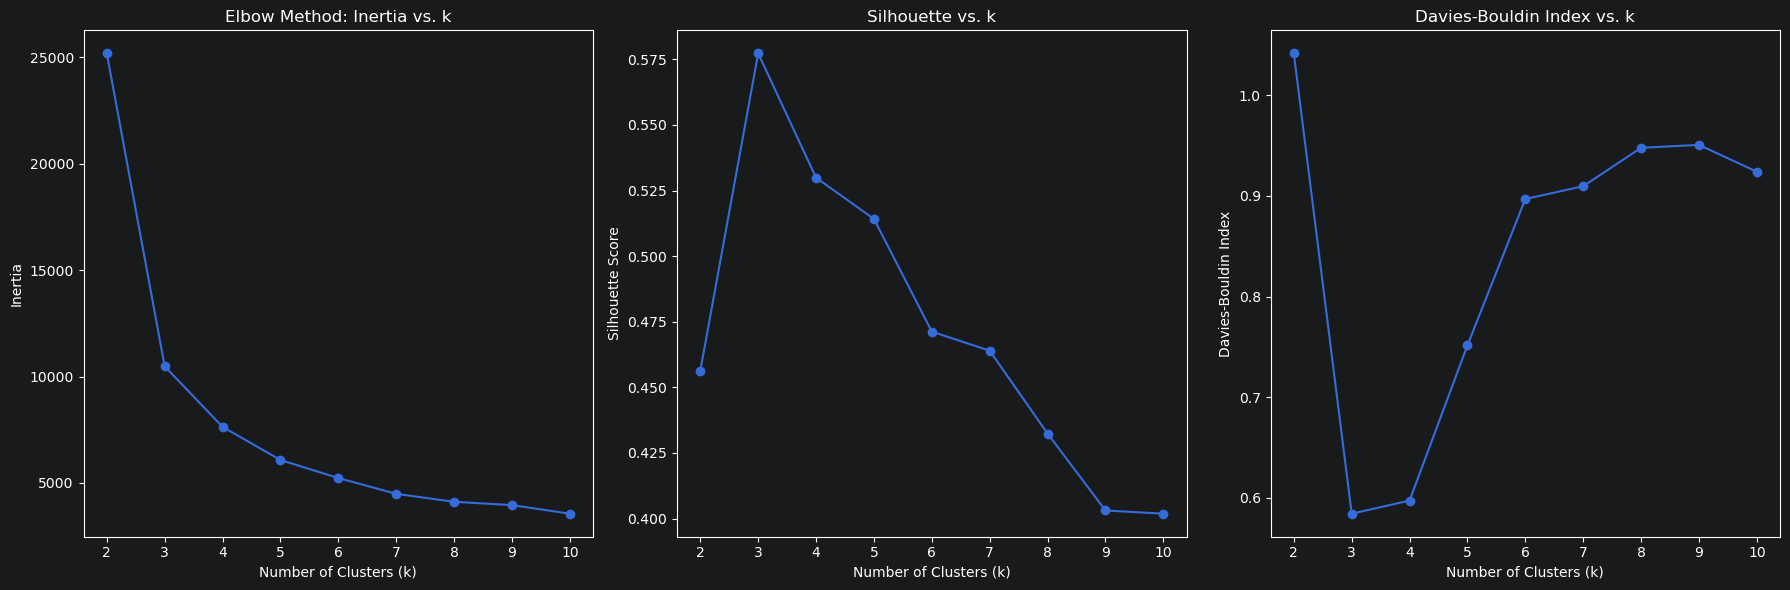

In [5]:
k_values = range(2, 11)

inertia_values = []
silhouette_scores = []
davies_bouldin_indices = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, y_kmeans))
    davies_bouldin_indices.append(davies_bouldin_score(X, y_kmeans))

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method: Inertia vs. k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette vs. k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.subplot(1, 3, 3)
plt.plot(k_values, davies_bouldin_indices, marker="o")
plt.title("Davies-Bouldin Index vs. k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")

plt.tight_layout()

<p>The first plot is often used in the <b>elbow method</b>, where the ideal value of k is chosen near the point where the curve starts to level off. Since inertia decreases as the number of clusters increases, it's important to find the balance where adding more clusters provides diminishing returns in reducing inertia. The inertia plot points to an optimal cluster number around 3 or 4. The silhouette score shows a clear peak at <code>k = 3</code>, while the Davies-Bouldin index reaches its lowest values between <code>k = 3</code> and <code>k = 4</code>.</p>
<p>Overall, these metrics suggest that three clusters may be optimal, although we know that the true number of clusters in this case is actually four.</p>

## Plot the blobs and the clustering results for `k = 3, 4 and 5`

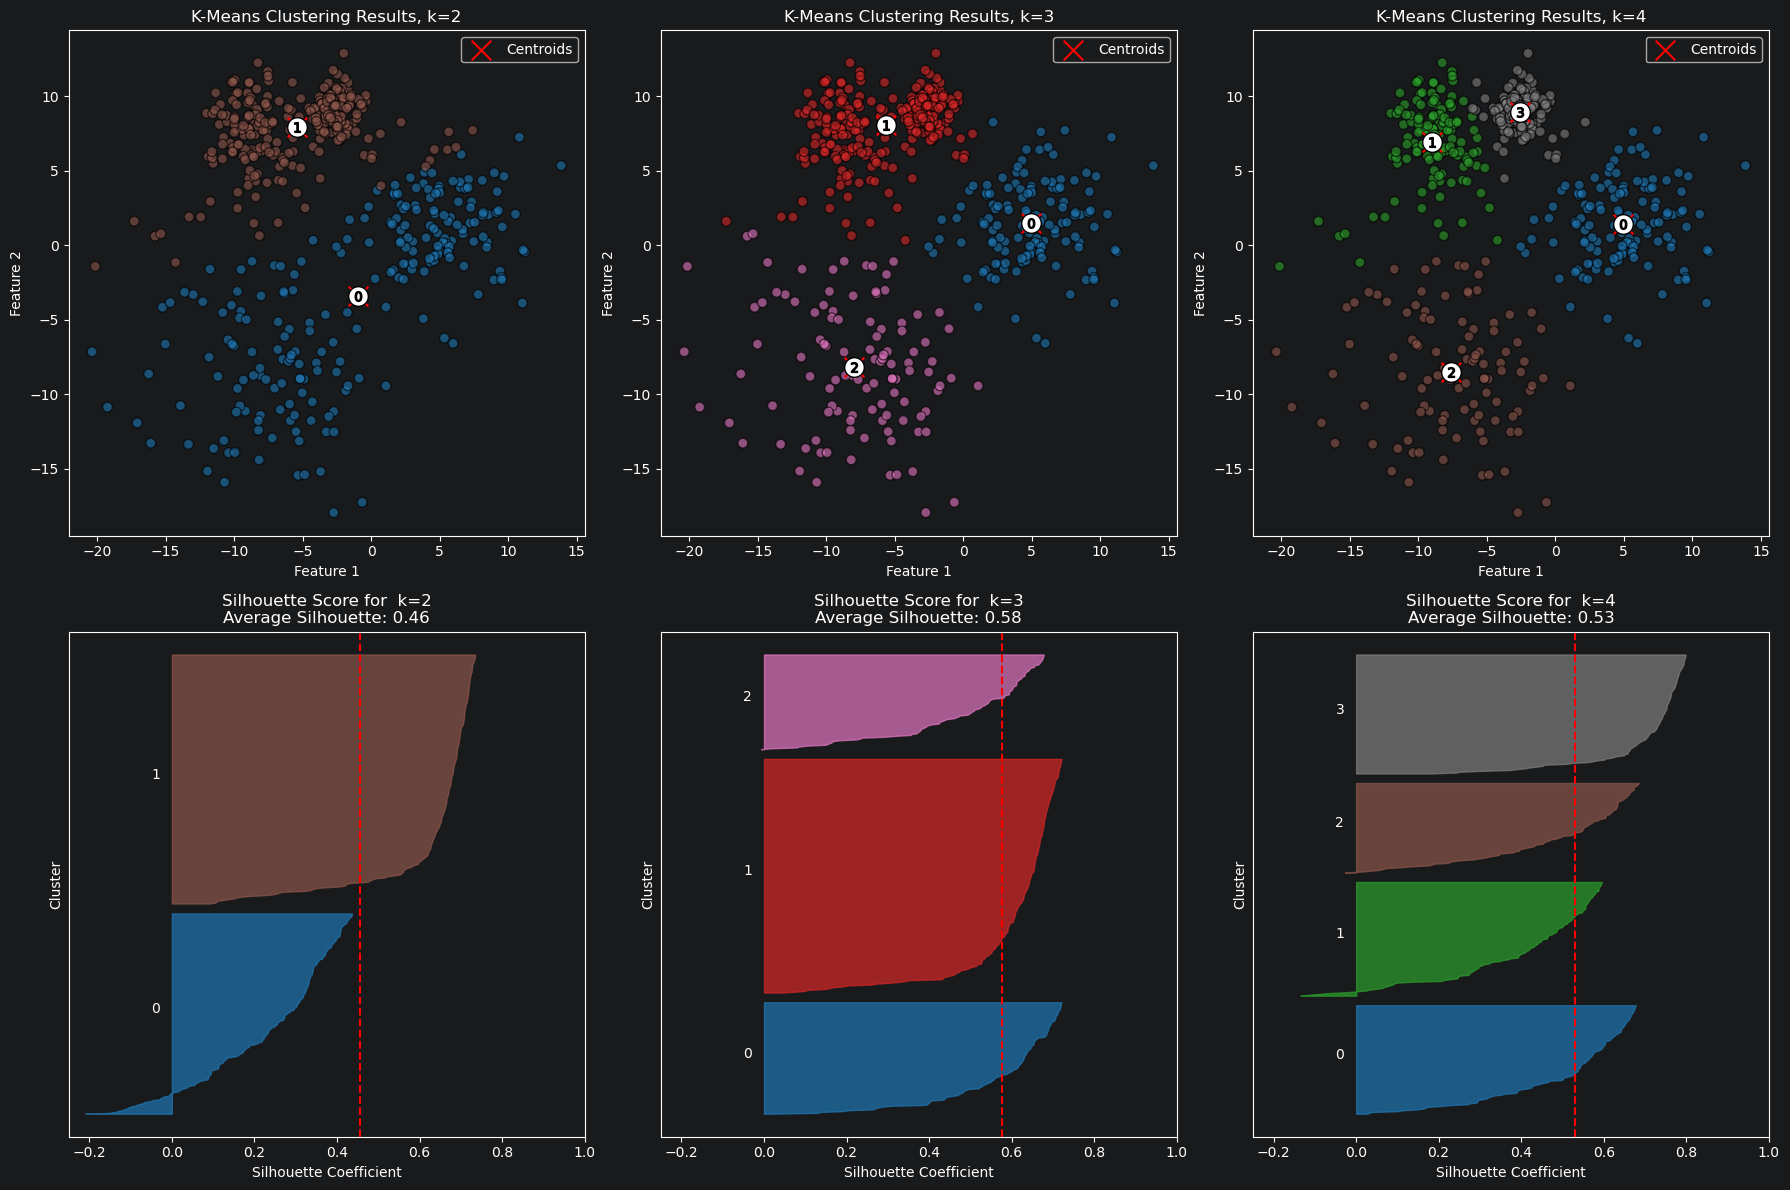

In [6]:
plt.figure(figsize=(18, 12))
colormap = mpl.colormaps["tab10"]

for i, k in enumerate([2, 3, 4]):
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    colors = colormap(y_kmeans.astype(float) / k)

    ax1 = plt.subplot(2, 3, i + 1)
    ax1.scatter(X[:, 0], X[:, 1], c=colors, s=50, alpha=0.6, edgecolor="k")
    ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="red", s=200, marker="x", label="Centroids")

    centers = kmeans.cluster_centers_
    ax1.scatter(centers[:, 0], centers[:, 1], marker="o", c="white", alpha=1, s=200, edgecolor="k")

    for idx, c in enumerate(centers):
        ax1.scatter(c[0], c[1], marker=f"${idx}$", alpha=1, s=50, edgecolor="k")

    ax1.set_title(f"K-Means Clustering Results, k={k}")
    ax1.set_xlabel("Feature 1")
    ax1.set_ylabel("Feature 2")
    ax1.legend()

    ax2 = plt.subplot(2, 3, i + 4)
    evaluate_clustering(X, y_kmeans, k, ax=ax2, title_suffix=f" k={k}")

plt.tight_layout()

<p>By examining the clustering results for <code>k = 2, 3 and 4</code>, it becomes apparent that the intuitive choice for the optimal number of clusters is four, although one could also argue for three. For <code>k=3</code>, the first cluster fails to distinguish between two regions with varying densities, whereas for <code>k=4</code>, these regions are split into two distinct clusters (clusters 1 and 3).</p>
<p>The silhouette plot for <code>k=4</code> shows relatively uniform block widths across clusters, suggesting clusters of similar sizes. However, the shape of these blocks indicates that many points are somewhat ambiguously assigned, highlighting that the clusters are not distinctly separated and may overlap to some extent.</p>
<p>Determining the <b>correct</b> number of clusters is not straightforward, as it often involves subjective judgment. Metrics alone point to <code>k=3</code> as being optimal, given that the silhouette plot for <code>k=3</code> shows better cluster separation, with higher and more consistent silhouette scores across clusters compared to other choices for k.</p>

## Limitations of k-means - Shape sensitivity

<p>Can you identify situations where K-means would not be appropriate? What alternatives could be used?</p>
<p>Let's explore these questions with an experiment. Using <code>make_classification</code> we'll create a labelled, 2-d dataset consisting of three classes. This time we'll have differently shaped sets of points in each class, not just spherical blobs.</p>

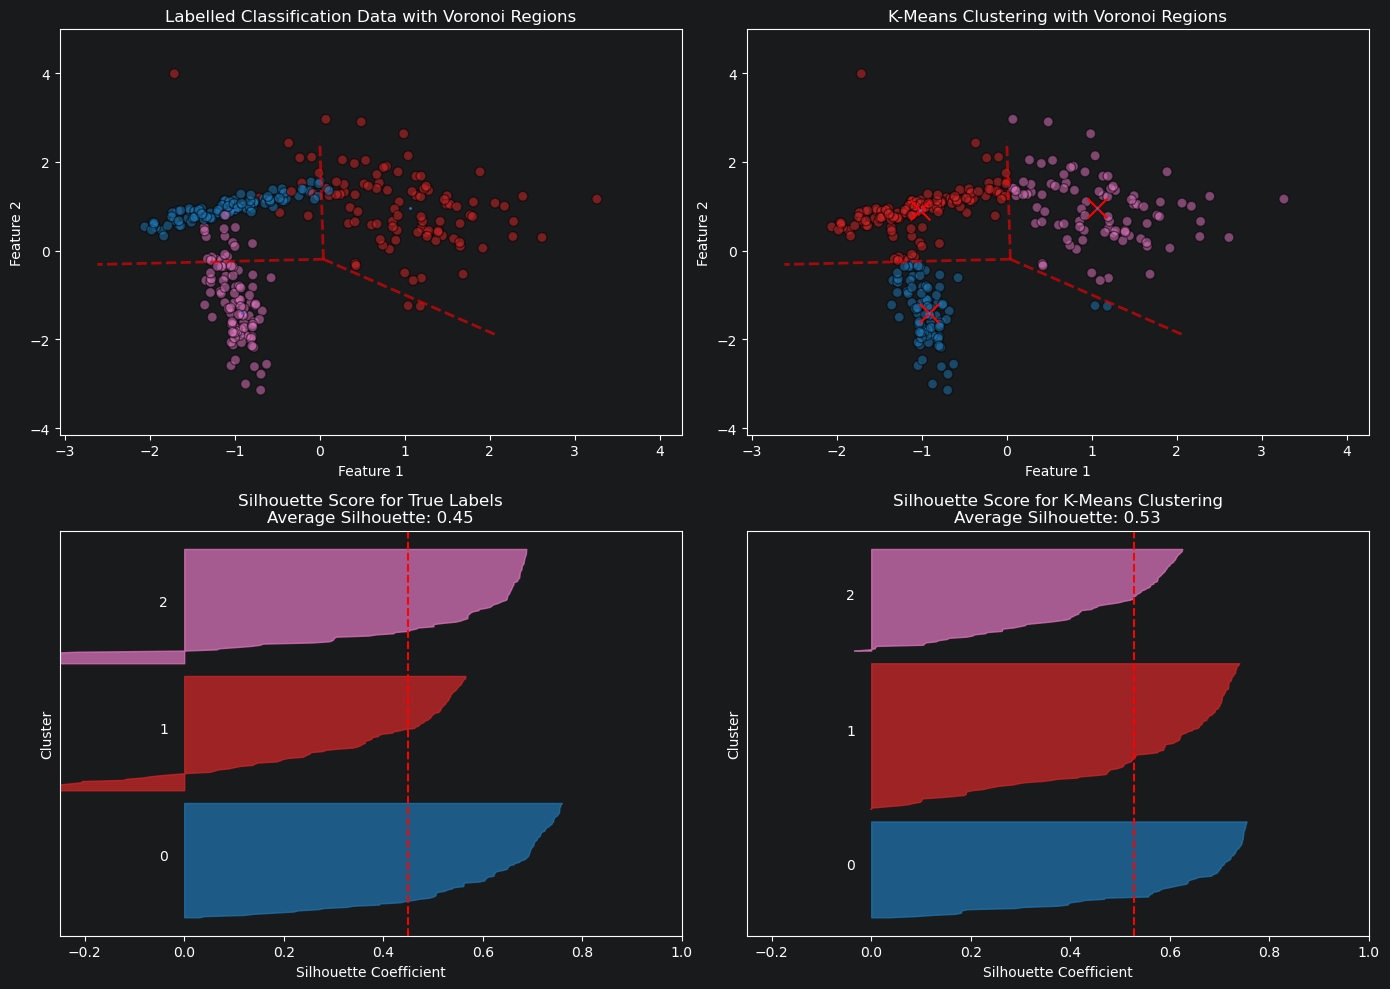

In [7]:
cls: tuple[NDArray[np.float64], NDArray[np.int64]] = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, n_classes=3, random_state=42)
X, y_true = cls

kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
vor = Voronoi(centroids)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

colormap = mpl.colormaps["tab10"]
colors_true = colormap(y_true.astype(float) / 3)
axes[0, 0].scatter(X[:, 0], X[:, 1], c=colors_true, s=50, alpha=0.5, ec="k")
voronoi_plot_2d(vor, ax=axes[0, 0], show_vertices=False, line_colors="red", line_width=2, line_alpha=0.6, point_size=2)
axes[0, 0].set_title("Labelled Classification Data with Voronoi Regions")
axes[0, 0].set_xlabel("Feature 1")
axes[0, 0].set_ylabel("Feature 2")
axes[0, 0].set_xlim(x_min, x_max)
axes[0, 0].set_ylim(y_min, y_max)

evaluate_clustering(X, y_true, n_clusters=3, ax=axes[1, 0], title_suffix="True Labels")

colors_kmeans = colormap(y_kmeans.astype(float) / 3)
axes[0, 1].scatter(X[:, 0], X[:, 1], c=colors_kmeans, s=50, alpha=0.5, ec="k")
axes[0, 1].scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="x", label="Centroids")
voronoi_plot_2d(vor, ax=axes[0, 1], show_vertices=False, line_colors="red", line_width=2, line_alpha=0.6, point_size=2)

axes[0, 1].set_title("K-Means Clustering with Voronoi Regions")
axes[0, 1].set_xlabel("Feature 1")
axes[0, 1].set_ylabel("Feature 2")
axes[0, 1].set_xlim(x_min, x_max)
axes[0, 1].set_ylim(y_min, y_max)

evaluate_clustering(X, y_kmeans, n_clusters=3, ax=axes[1, 1], title_suffix="K-Means Clustering")

plt.tight_layout()

<p>K-means did a good job of identifying three clusters that mostly agree with the three classes. However, looking at the finer details, k-means wasn't able to fully capture the inherent conherence of the two linearly shaped classes (purple and green).</p>
<p>Another thing to notice is that the clusters are partitioned in a way that doesn't capture the density of the classes.</p>
<p>The red dashed lines in the scatter plots indicate the boundaries between the <b>voronoi</b> regions that separate the clusters. This partitioning method inherently assumes spherical cluster shapes and can misclassify points where the true distribution is curved or linear. For instance, a few points belonging to the elongated purple class were mislabeled, falling into the bottom section of the more spherical cluster. Similarly, the green points between the two green and purple clusters were mislabeled.</p>
<p>Interestingly, the silhouette score is higher for the clustering result than it for the actual class labels. This is appropriate though since the actual class labels. This is appropriate though since the actual classes slightly overlap, as is also indicated by the negative values in the silhouette plot for the pink and red classes.</p>
<p>Go ahead and explore some different approaches. Of course, in real world clustering problems, you don't have the benefit of knowing the answer like we did in this experiment, so you will need to be creative. The K-means algorithm performed reasonably well in identifying three clusters that mostly align with the true class labels. However, a closer examination reveals that K-means struggles to accurately capture the elongated, linear structure of the two classes (represented in purple and green).</p>
<p>One notable limitation is that K-means does not effectively account for the density distribution of points. The resulting clusters are separated by <b>Voronoi</b> boundaries (indicated by the red dashed lines), which split the space into regions that are equidistant to the nearest centroids. This approach inherently assumes spherical shapes for clusters and can misclassify points if the true distribution deviates from this assumption.</p>
<p>Similarly, some green points situated between the main green and purple clusters were also labeled incorrectly. This highlights K-means' inability to fully respect the density-based continuity of data.</p>
<p>A more flexible clustering approach, such as DBSCAN (Density-Based Spatial Clustering of Applications with Noise), might be more suitable for this type of data. DBSCAN takes density into account and can identify clusters of varying shapes and sizes, potentially capturing the true structure of the data more effectively.</p>
<p>In real-world clustering tasks, the ground truth is not known, so exploring multiple algorithms and adapting them to the specific data characteristics is essential. Testing different methods like DBSCAN or hierarchical clustering, which consider density and proximity in non-linear ways, could provide better results for complex datasets.</p>

****
This is the end of the file.
****